<a href="https://colab.research.google.com/github/skolix15/Deep_Recurrent_Neural_Networks/blob/main/drnn_stl10_vit_executed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2 — Vision Transformer (ViT-B/16): Feature Extraction vs Fine-tuning (STL10)
**Dataset:** STL10 | **Model:** ViT-B/16 pretrained on ImageNet

## Research Question
How does a Vision Transformer compare to a CNN (ResNet18 from Assignment 1)
when using transfer learning on the same datasets with the same strategies?

## What is ViT-B/16?
ViT-B/16 divides the input image into 16x16 pixel patches (hence '/16').
Each patch is flattened and projected to a 768-d vector called a token.
A special [CLS] token is prepended. All tokens are processed by a Transformer
encoder that computes attention between every pair of patches simultaneously.
The final [CLS] token is used for classification.
Unlike CNNs which build context gradually, ViT has global context from layer 1.

## Key difference from Assignment 1
- ResNet18: 11M params, CNN, local receptive fields
- ViT-B/16: 86M params, Transformer, global attention
- Everything else (datasets, training loop, evaluation) is identical

## Structure
1. Imports and setup
2. CIFAR-10 data loading
3. Model A: Feature Extraction (head only)
4. Model B: Fine-tuning (last 2 transformer blocks + head)
5. Training and evaluation
6. Comparison — accuracy, loss curves, confusion matrix
7. Grad-CAM visualization
8. Final table: ViT vs ResNet18

## 1. Imports & Setup

In [1]:
# --- Core deep learning framework ---
# Same imports as Assignment 1 — nothing changes here.
# torch.nn contains all layer types (Linear, Dropout, etc.)
# torch.optim contains optimizers (Adam, SGD, etc.)
import torch
import torch.nn as nn
import torch.optim as optim

# --- Computer vision utilities ---
# torchvision gives us: pretrained models (including ViT), standard datasets,
# and image transforms (resize, normalize, augment)
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

# --- Standard utilities ---
import numpy as np
import matplotlib.pyplot as plt
import time   # to measure training duration
import copy   # to save a deep copy of the best model weights

# --- Evaluation metrics (from sklearn, not PyTorch) ---
# We use sklearn only for evaluation, NOT for training the ViT.
# confusion_matrix: shows which classes get confused with each other
# classification_report: precision, recall, F1 per class
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns  # nicer heatmap plots

# --- Device setup ---
# ViT is significantly larger than ResNet18 (86M vs 11M params).
# GPU is especially important here — CPU training would be very slow.
# In Colab: Runtime -> Change runtime type -> T4 GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# --- Global hyperparameters ---
# The EPOCHS value was set to 10 because of training and testing time.
# BATCH_SIZE is reduced from 128 to 64 because ViT uses more GPU memory
# per image than ResNet18 (larger model = more activations stored in memory).
EPOCHS      = 10
BATCH_SIZE  = 64          # reduced from 128 (ResNet18) due to ViT memory usage
NUM_CLASSES = 10          # STL10 has 10 categories
CLASSES = ['airplane', 'bird', 'car', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

# --- ImageNet normalization statistics ---
# ViT-B/16 was also pretrained on ImageNet — same mean/std as ResNet18.
# We must use these exact values so the pretrained weights work correctly.
IMAGENET_MEAN = [0.485, 0.456, 0.406]  # mean per R, G, B channel
IMAGENET_STD  = [0.229, 0.224, 0.225]  # std  per R, G, B channel

Using device: cuda
GPU: Tesla T4


## 2. Data Loading — STL10

In [2]:
# --- Why we resize to 224x224 ---
# STL10 images are 96x96 pixels — higher resolution than CIFAR-10.
# ViT-B/16 was trained on ImageNet with 224x224 images.
# With patch size 16, a 224x224 image produces (224/16)^2 = 196 patches.
# If we fed 96x96 directly, we would only get (96/16)^2 = 36 patches —
# fewer than the 196 the model expects. Resizing to 224x224 is cleaner.
# Solution: resize every image to 224x224 before feeding into ViT.
# STL10 at 96x96 requires much less upscaling than CIFAR-10 (32x32).

# --- Training transforms (with data augmentation) ---
# Data augmentation artificially increases dataset diversity.
# RandomHorizontalFlip: randomly mirrors the image left-right (50% chance)
# RandomCrop: randomly crops a 224x224 patch with 8px padding around edges
# These are identical to Assignment 1 for fair comparison.
train_transform = transforms.Compose([
    transforms.Resize(224),              # upsample from 96x96 to 224x224
    transforms.RandomHorizontalFlip(),   # augmentation: random mirror
    transforms.RandomCrop(224, padding=8),  # augmentation: random crop
    transforms.ToTensor(),               # convert PIL image to tensor, scales to [0, 1]
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)  # normalize
])

# --- Validation/Test transforms (NO augmentation) ---
# For evaluation we want deterministic results — no random flips or crops.
# Just resize and normalize, same as the training data distribution.
val_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# --- Download and load STL10 ---
# split='train' -> 5,000 training images (10x fewer than CIFAR-10!)
# split='test'  -> 8,000 test images
# download=True automatically fetches the dataset the first time
train_dataset = torchvision.datasets.STL10(
    root='./data',
    split='train',
    download=True,
    transform=train_transform
)
test_dataset = torchvision.datasets.STL10(
    root='./data',
    split='test',
    download=True,
    transform=val_transform
)

# --- Validation split ---
# We carve out 10% of the training set as validation data.
# Validation is used to monitor overfitting DURING training (not for final score).
# The test set is only used ONCE at the very end.
val_size   = int(0.1 * len(train_dataset))  # 500 images
train_size = len(train_dataset) - val_size  # 4,500 images
train_set, val_set = torch.utils.data.random_split(
    train_dataset, [train_size, val_size])

# --- DataLoaders ---
# A DataLoader handles batching, shuffling, and parallel data loading.
# shuffle=True for training: different batch order each epoch
# shuffle=False for val/test: order doesn't matter for evaluation
# num_workers=0  # macOS: avoid multiprocessing issues: 2 CPU threads load data in parallel while GPU trains
train_loader = torch.utils.data.DataLoader(
    train_set,    batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)  # macOS: avoid multiprocessing issues
val_loader   = torch.utils.data.DataLoader(
    val_set,      batch_size=BATCH_SIZE, shuffle=False, num_workers=0)  # macOS: avoid multiprocessing issues
test_loader  = torch.utils.data.DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)  # macOS: avoid multiprocessing issues

print(f'Train: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_dataset)}')

100%|██████████| 2.64G/2.64G [00:48<00:00, 54.5MB/s]


Train: 4500 | Val: 500 | Test: 8000


## 3. Build Models

In [3]:
# =============================================================================
# HOW ViT-B/16 IS STRUCTURED (simplified)
# =============================================================================
# Input image (224x224)
#   -> split into 196 patches of 16x16 pixels each
#   -> each patch linearly projected to a 768-d vector (the 'embedding')
#   -> prepend a special [CLS] token (also 768-d)
#   -> add positional embeddings so the model knows patch order
#   -> pass through 12 Transformer encoder blocks
#        each block: LayerNorm -> Multi-Head Attention -> LayerNorm -> MLP
#   -> take the final [CLS] token -> 768-d representation of the whole image
#   -> model.heads.head: Linear(768 -> 1000) for ImageNet classification
#
# KEY DIFFERENCE from ResNet18:
#   ResNet18 head: model.fc         -> Linear(512 -> 1000)
#   ViT-B/16 head: model.heads.head -> Linear(768 -> 1000)
#   So we replace model.heads.head instead of model.fc
# =============================================================================


# =============================================================================
# MODEL A — Feature Extraction
# =============================================================================
# Strategy: freeze ALL layers of ViT, replace only the final head.
#
# Why this works:
#   ViT trained on ImageNet produces rich 768-d image representations via
#   self-attention. The [CLS] token captures global image context.
#   We simply replace the final linear layer to output 10 classes instead of 1000.
#
# What we train:
#   Only the new head: Dropout + Linear(768 -> 10)
#   That's ~7,690 parameters — similar to ResNet18 FE (~5,130 params).
#
# Limitation:
#   The transformer blocks were tuned for ImageNet's 1000 classes.
#   They may not produce the most discriminative features for STL10.
# =============================================================================
def build_feature_extraction():
    # Load ViT-B/16 with weights pretrained on ImageNet
    # ViT-B/16: B = Base size, /16 = patch size 16x16
    # These weights encode ~86M parameters learned from 1.2M images
    model = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)

    # Freeze ALL parameters: set requires_grad=False
    # PyTorch will NOT compute gradients for these — they stay fixed.
    for param in model.parameters():
        param.requires_grad = False

    # Replace the original classification head
    # ViT stores its head at model.heads.head (unlike ResNet's model.fc)
    # in_features = 768 (the [CLS] token dimension in ViT-B/16)
    in_features = model.heads.head.in_features  # 768
    model.heads.head = nn.Sequential(
        nn.Dropout(0.3),                         # randomly zero 30% of neurons
        nn.Linear(in_features, NUM_CLASSES)      # 768 -> 10
    )
    # The new head has requires_grad=True by default — only it will be trained.
    return model


# =============================================================================
# MODEL B — Fine-tuning
# =============================================================================
# Strategy: freeze early transformer blocks, unfreeze last 2 blocks + head.
#
# ViT-B/16 architecture:
#   patch_embed -> encoder.layers[0..11] (12 blocks) -> heads.head
#   [FROZEN]       [FROZEN 0..9] [UNFREEZE 10,11]      [TRAIN]
#
# Why unfreeze only the last 2 blocks?
#   Early blocks learn general patch embeddings and low-level attention —
#   edges, textures — that transfer well to any image dataset.
#   Later blocks learn task-specific, high-level representations.
#   Unfreezing blocks 10 and 11 lets the model adapt to STL10's patterns
#   without disturbing the general features in the earlier blocks.
#
# Why use a smaller learning rate (1e-4 instead of 1e-3)?
#   The pretrained weights in blocks 10/11 are already good.
#   A large lr would overwrite these (catastrophic forgetting).
#   A small lr gently adapts them without losing ImageNet knowledge.
# =============================================================================
def build_fine_tuning():
    model = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)

    # Step 1: freeze everything first
    for param in model.parameters():
        param.requires_grad = False

    # Step 2: unfreeze the last 2 transformer encoder blocks (indices 10 and 11)
    # ViT-B/16 has 12 encoder blocks total (0 to 11)
    # Each block contains: LayerNorm, Multi-Head Self-Attention, LayerNorm, MLP
    for param in model.encoder.layers[-2].parameters():
        param.requires_grad = True
    for param in model.encoder.layers[-1].parameters():
        param.requires_grad = True

    # Step 3: also unfreeze the final LayerNorm before the head
    # This normalizes the [CLS] token before classification — important to adapt
    # so the head receives properly normalized representations
    for param in model.encoder.ln.parameters():
        param.requires_grad = True

    # Step 4: replace the classification head (same as feature extraction)
    in_features = model.heads.head.in_features  # 768
    model.heads.head = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_features, NUM_CLASSES)
    )
    return model


def count_trainable_params(model):
    # Count only parameters with requires_grad=True
    # These are the only parameters updated during training
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# Instantiate both models and move them to GPU
model_fe = build_feature_extraction().to(device)
model_ft = build_fine_tuning().to(device)

print(f'Feature Extraction — trainable params: {count_trainable_params(model_fe):,}')
print(f'Fine-tuning        — trainable params: {count_trainable_params(model_ft):,}')
# Expected:
# Feature Extraction — trainable params: ~7,690
# Fine-tuning        — trainable params: ~14,000,000

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 173MB/s]


Feature Extraction — trainable params: 7,690
Fine-tuning        — trainable params: 14,184,970


## 4. Training Loop

In [4]:
# This training loop is IDENTICAL to Assignment 1.
# The same code works for both ResNet18 and ViT because PyTorch abstracts
# away the architecture — we just call model(inputs) and it handles the rest.
def train_model(model, train_loader, val_loader, epochs, lr, model_name):
    """
    Train a model for a given number of epochs and return:
      - the model with the best validation accuracy (not the last epoch)
      - training history (loss/accuracy per epoch)
      - total training time in seconds
    """

    # --- Loss function ---
    # CrossEntropyLoss = Softmax + Negative Log Likelihood combined.
    # L = -log( exp(z_y) / sum(exp(z_j)) )  where z_y is the true class score.
    # The model is penalized more when it is confident AND wrong.
    criterion = nn.CrossEntropyLoss()

    # --- Optimizer ---
    # Adam adapts the learning rate per parameter using gradient history.
    # IMPORTANT: we pass only parameters with requires_grad=True.
    # Frozen parameters are excluded — no wasted computation.
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr
    )

    # --- Learning rate scheduler ---
    # StepLR halves the learning rate every 5 epochs.
    # Epoch  1-5:  lr = initial
    # Epoch  6-10: lr = initial * 0.5
    # Epoch 11-15: lr = initial * 0.25
    # Smaller lr in later epochs = finer adjustments near the optimum.
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    # --- Best model tracking ---
    # We save the weights with the highest validation accuracy.
    # ViT is prone to overfitting in later epochs — this prevents using
    # an overfitted checkpoint for final evaluation.
    best_val_acc = 0.0
    best_weights = copy.deepcopy(model.state_dict())
    start = time.time()

    for epoch in range(epochs):

        # =====================================================================
        # TRAINING PHASE
        # =====================================================================
        # model.train() enables Dropout and sets LayerNorm to training mode
        # (uses batch statistics instead of running statistics).
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            # Zero gradients from previous batch.
            # PyTorch accumulates gradients — we reset them each step.
            optimizer.zero_grad()

            # Forward pass: feed batch through ViT -> get logits
            # Inside: patch embedding -> positional encoding ->
            #         12 transformer blocks -> [CLS] token -> head -> logits
            outputs = model(inputs)  # shape: (batch_size, NUM_CLASSES)

            # Compute loss between predictions and true labels
            loss = criterion(outputs, labels)

            # Backward pass: compute dL/dW for all trainable parameters
            # In ViT: gradients flow through the head and (for FT) the
            # last 2 transformer blocks via backpropagation through attention.
            loss.backward()

            # Update weights: W = W - lr * dL/dW  (Adam version)
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted  = outputs.max(1)
            total        += labels.size(0)
            correct      += predicted.eq(labels).sum().item()

        train_loss = running_loss / total
        train_acc  = correct / total

        # =====================================================================
        # VALIDATION PHASE
        # =====================================================================
        # model.eval() disables Dropout and switches LayerNorm to use
        # running statistics. torch.no_grad() disables gradient computation.
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss    = criterion(outputs, labels)
                val_loss    += loss.item() * inputs.size(0)
                _, predicted = outputs.max(1)
                val_total   += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        val_loss /= val_total
        val_acc   = val_correct / val_total

        # Save checkpoint if this is the best validation accuracy so far
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = copy.deepcopy(model.state_dict())

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        # Step the scheduler once per epoch (not per batch)
        scheduler.step()

        print(f'[{model_name}] Epoch {epoch+1:2d}/{epochs} | '
              f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
              f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}')

    elapsed = time.time() - start
    print(f'\n{model_name} — Best Val Acc: {best_val_acc:.4f} | Time: {elapsed:.1f}s')

    # Restore best weights (not necessarily from the last epoch)
    model.load_state_dict(best_weights)
    return model, history, elapsed

In [5]:
# --- Train Model A: Feature Extraction ---
# lr=1e-3: higher learning rate is safe since only the new head is trained.
# No pretrained weights are at risk of being overwritten.
print('=' * 60)
print('TRAINING: Feature Extraction on STL10')
print('Only the final head (~7,690 params) is updated.')
print('=' * 60)
model_fe, history_fe, time_fe = train_model(
    model_fe, train_loader, val_loader,
    epochs=EPOCHS, lr=1e-3, model_name='FeatureExtraction'
)

TRAINING: Feature Extraction on STL10
Only the final head (~7,690 params) is updated.
[FeatureExtraction] Epoch  1/10 | Train Loss: 0.6602 Acc: 0.8827 | Val Loss: 0.1684 Acc: 0.9820
[FeatureExtraction] Epoch  2/10 | Train Loss: 0.1485 Acc: 0.9764 | Val Loss: 0.1154 Acc: 0.9820
[FeatureExtraction] Epoch  3/10 | Train Loss: 0.0957 Acc: 0.9836 | Val Loss: 0.1015 Acc: 0.9740
[FeatureExtraction] Epoch  4/10 | Train Loss: 0.0758 Acc: 0.9858 | Val Loss: 0.0821 Acc: 0.9760
[FeatureExtraction] Epoch  5/10 | Train Loss: 0.0601 Acc: 0.9887 | Val Loss: 0.0669 Acc: 0.9860
[FeatureExtraction] Epoch  6/10 | Train Loss: 0.0509 Acc: 0.9904 | Val Loss: 0.0664 Acc: 0.9780
[FeatureExtraction] Epoch  7/10 | Train Loss: 0.0448 Acc: 0.9918 | Val Loss: 0.0720 Acc: 0.9840
[FeatureExtraction] Epoch  8/10 | Train Loss: 0.0436 Acc: 0.9929 | Val Loss: 0.0647 Acc: 0.9780
[FeatureExtraction] Epoch  9/10 | Train Loss: 0.0388 Acc: 0.9924 | Val Loss: 0.0611 Acc: 0.9780
[FeatureExtraction] Epoch 10/10 | Train Loss: 0.03

In [6]:
# --- Train Model B: Fine-tuning ---
# lr=1e-4: smaller learning rate to protect the pretrained transformer blocks.
# The last 2 blocks have already learned useful attention patterns on ImageNet.
# A large lr would destroy these (catastrophic forgetting).
print('=' * 60)
print('TRAINING: Fine-tuning on STL10')
print('Encoder blocks 10, 11 + LayerNorm + head are updated.')
print('=' * 60)
model_ft, history_ft, time_ft = train_model(
    model_ft, train_loader, val_loader,
    epochs=EPOCHS, lr=1e-4, model_name='FineTuning'
)

TRAINING: Fine-tuning on STL10
Encoder blocks 10, 11 + LayerNorm + head are updated.
[FineTuning] Epoch  1/10 | Train Loss: 0.4214 Acc: 0.8978 | Val Loss: 0.0724 Acc: 0.9780
[FineTuning] Epoch  2/10 | Train Loss: 0.0306 Acc: 0.9933 | Val Loss: 0.0523 Acc: 0.9800
[FineTuning] Epoch  3/10 | Train Loss: 0.0149 Acc: 0.9969 | Val Loss: 0.0522 Acc: 0.9820
[FineTuning] Epoch  4/10 | Train Loss: 0.0074 Acc: 0.9991 | Val Loss: 0.0534 Acc: 0.9780
[FineTuning] Epoch  5/10 | Train Loss: 0.0069 Acc: 0.9982 | Val Loss: 0.0548 Acc: 0.9860
[FineTuning] Epoch  6/10 | Train Loss: 0.0024 Acc: 1.0000 | Val Loss: 0.0478 Acc: 0.9860
[FineTuning] Epoch  7/10 | Train Loss: 0.0027 Acc: 0.9998 | Val Loss: 0.0636 Acc: 0.9800
[FineTuning] Epoch  8/10 | Train Loss: 0.0029 Acc: 0.9998 | Val Loss: 0.0548 Acc: 0.9860
[FineTuning] Epoch  9/10 | Train Loss: 0.0016 Acc: 1.0000 | Val Loss: 0.0508 Acc: 0.9840
[FineTuning] Epoch 10/10 | Train Loss: 0.0013 Acc: 1.0000 | Val Loss: 0.0413 Acc: 0.9880

FineTuning — Best Val Ac

## 5. Evaluation on the Test Set

In [7]:
def evaluate(model, loader):
    # Run the model on the full test set and collect predictions.
    # model.eval() + torch.no_grad() = inference mode (no training overhead).
    # Returns numpy arrays so we can use sklearn metrics.
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = outputs.max(1)  # argmax across class dimension
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)


labels_fe, preds_fe = evaluate(model_fe, test_loader)
labels_ft, preds_ft = evaluate(model_ft, test_loader)

acc_fe = (labels_fe == preds_fe).mean()
acc_ft = (labels_ft == preds_ft).mean()

print(f'Test Accuracy — Feature Extraction : {acc_fe*100:.2f}%')
print(f'Test Accuracy — Fine-tuning        : {acc_ft*100:.2f}%')
print(f'Accuracy gain from fine-tuning     : {(acc_ft - acc_fe)*100:+.2f}%')

Test Accuracy — Feature Extraction : 98.45%
Test Accuracy — Fine-tuning        : 99.05%
Accuracy gain from fine-tuning     : +0.60%


## 6. Comparison — Learning Curves & Confusion Matrix

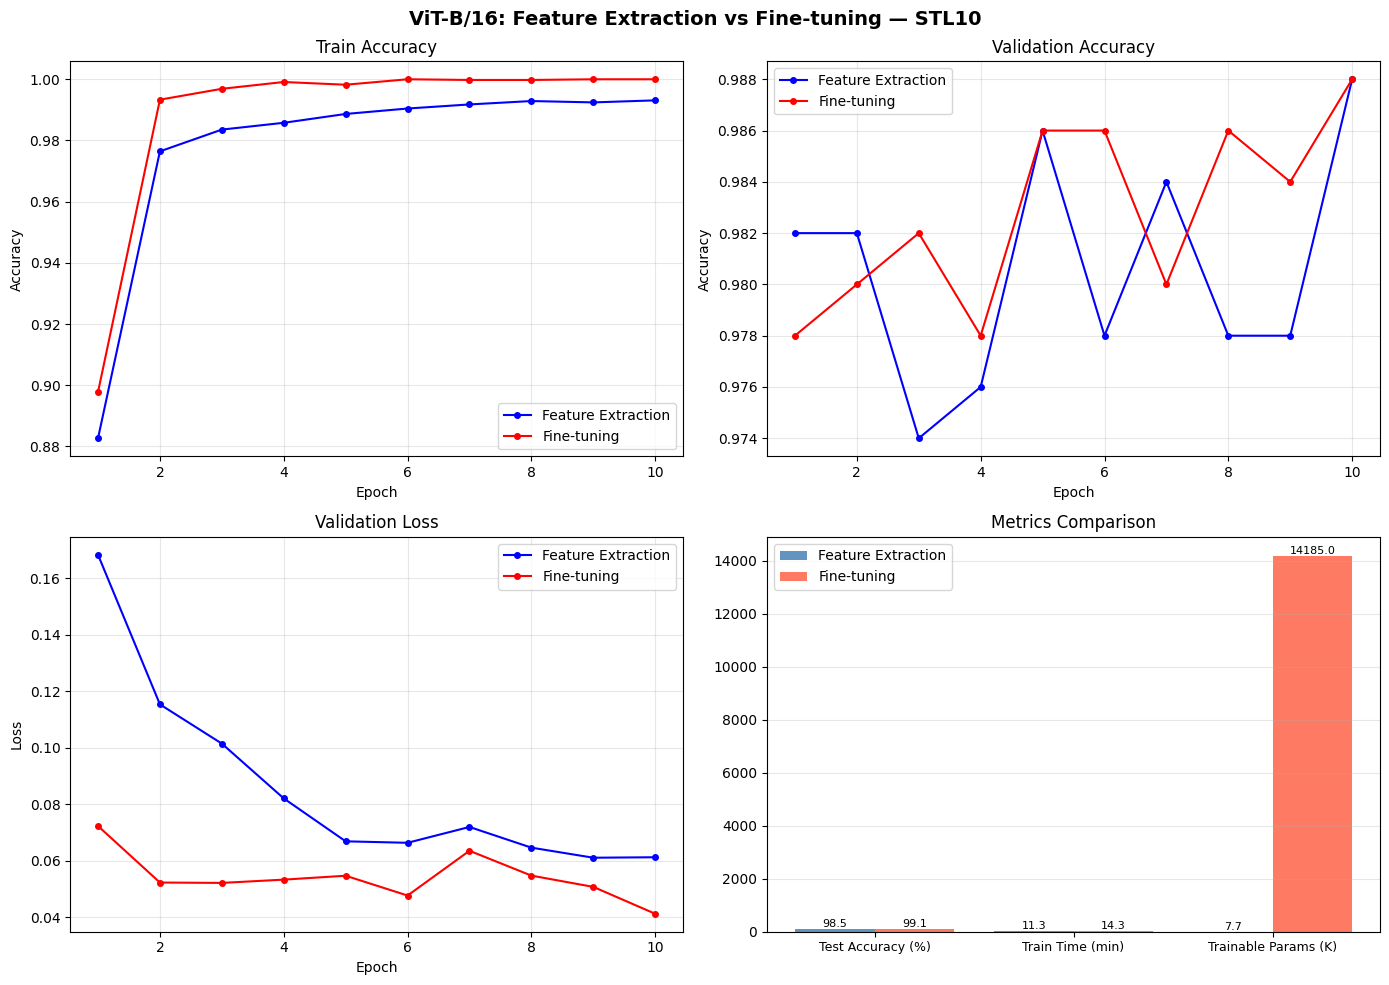

Saved: vit_cifar10_comparison_curves.png


In [8]:
# --- Learning Curves ---
# Train vs Val accuracy per epoch tells us:
#   - If train >> val -> overfitting (model memorized training data)
#   - If both are low -> underfitting (model has not learned enough)
#   - Ideal: both converge and stay close
#
# Compare these curves with Assignment 1 (ResNet18):
#   - Does ViT converge faster or slower?
#   - Is the FE vs FT gap larger or smaller than ResNet18?

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('ViT-B/16: Feature Extraction vs Fine-tuning — STL10',
             fontsize=14, fontweight='bold')
epochs_range = range(1, EPOCHS + 1)

# Train Accuracy
axes[0, 0].plot(epochs_range, history_fe['train_acc'], 'b-o', markersize=4, label='Feature Extraction')
axes[0, 0].plot(epochs_range, history_ft['train_acc'], 'r-o', markersize=4, label='Fine-tuning')
axes[0, 0].set_title('Train Accuracy')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Validation Accuracy — most important curve
axes[0, 1].plot(epochs_range, history_fe['val_acc'], 'b-o', markersize=4, label='Feature Extraction')
axes[0, 1].plot(epochs_range, history_ft['val_acc'], 'r-o', markersize=4, label='Fine-tuning')
axes[0, 1].set_title('Validation Accuracy')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Validation Loss
# If val loss rises while train loss falls -> overfitting
axes[1, 0].plot(epochs_range, history_fe['val_loss'], 'b-o', markersize=4, label='Feature Extraction')
axes[1, 0].plot(epochs_range, history_ft['val_loss'], 'r-o', markersize=4, label='Fine-tuning')
axes[1, 0].set_title('Validation Loss')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Summary bar chart
metrics = ['Test Accuracy (%)', 'Train Time (min)', 'Trainable Params (K)']
fe_vals = [acc_fe * 100, time_fe / 60, count_trainable_params(model_fe) / 1000]
ft_vals = [acc_ft * 100, time_ft / 60, count_trainable_params(model_ft) / 1000]
x = np.arange(len(metrics))
bars1 = axes[1, 1].bar(x - 0.2, fe_vals, 0.4, label='Feature Extraction', color='steelblue', alpha=0.85)
bars2 = axes[1, 1].bar(x + 0.2, ft_vals, 0.4, label='Fine-tuning',        color='tomato',    alpha=0.85)
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(metrics, fontsize=9)
axes[1, 1].set_title('Metrics Comparison')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')
for bar in bars1:
    axes[1, 1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                    f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    axes[1, 1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                    f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('vit_stl10_comparison_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: vit_cifar10_comparison_curves.png')

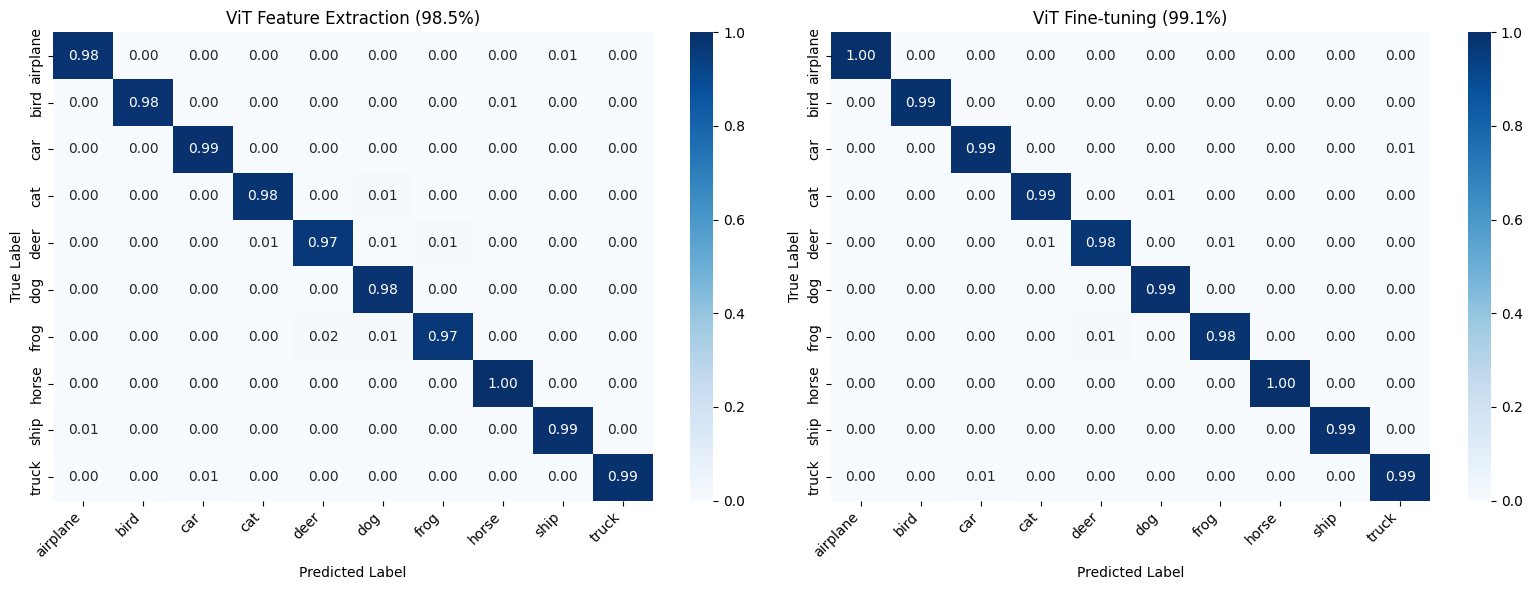


--- Classification Report: Feature Extraction ---
              precision    recall  f1-score   support

    airplane       0.99      0.98      0.99       800
        bird       0.99      0.98      0.99       800
         car       0.99      0.99      0.99       800
         cat       0.99      0.98      0.98       800
        deer       0.98      0.97      0.97       800
         dog       0.96      0.98      0.97       800
        frog       0.98      0.97      0.97       800
       horse       0.99      1.00      0.99       800
        ship       0.99      0.99      0.99       800
       truck       0.99      0.99      0.99       800

    accuracy                           0.98      8000
   macro avg       0.98      0.98      0.98      8000
weighted avg       0.98      0.98      0.98      8000


--- Classification Report: Fine-tuning ---
              precision    recall  f1-score   support

    airplane       0.99      1.00      1.00       800
        bird       0.99      0.99    

In [9]:
# --- Confusion Matrices ---
# Rows = true labels, Columns = predicted labels.
# Diagonal = correct predictions. Off-diagonal = mistakes.
# Normalized by row -> each cell shows recall per class:
#   cell[i][j] = P(predict class j | true class is i)
#
# Common STL10 confusions: cat<->dog, deer<->horse, car<->truck.
# Compare with ViT CIFAR-10 matrices and Assignment 1 ResNet18 matrices:
# Does ViT make the same mistakes or different ones?

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, labels, preds, title in [
    (axes[0], labels_fe, preds_fe, f'ViT Feature Extraction ({acc_fe*100:.1f}%)'),
    (axes[1], labels_ft, preds_ft, f'ViT Fine-tuning ({acc_ft*100:.1f}%)')
]:
    cm = confusion_matrix(labels, preds)
    # Normalize: divide each row by its sum to get per-class recall
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_norm, annot=True, fmt='.2f', ax=ax,
                xticklabels=CLASSES, yticklabels=CLASSES,
                cmap='Blues', vmin=0, vmax=1)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('vit_stl10_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# Precision: of all predicted as X, how many were actually X?
# Recall:    of all true X, how many did we predict correctly?
# F1:        harmonic mean of precision and recall
print('\n--- Classification Report: Feature Extraction ---')
print(classification_report(labels_fe, preds_fe, target_names=CLASSES))
print('\n--- Classification Report: Fine-tuning ---')
print(classification_report(labels_ft, preds_ft, target_names=CLASSES))

## 7. Grad-CAM Visualization

In [10]:
# =============================================================================
# GRAD-CAM FOR ViT — important difference from ResNet18
# =============================================================================
# In ResNet18 we hooked into the last conv layer (layer4[1].conv2).
# ViT has NO conv layers in the main encoder — it uses attention.
#
# Instead we hook into the MLP output of the last transformer block:
#   model.encoder.layers[-1].mlp
# This produces a (batch, 197, 768) tensor:
#   197 tokens = 196 patch tokens + 1 [CLS] token
#   768 = hidden dimension
#
# We skip the [CLS] token, reshape the 196 patch tokens to a 14x14 grid,
# and apply Grad-CAM the same way as for ResNet18.
#
# Note: ViT Grad-CAM maps look blockier than ResNet18 maps because
# ViT operates on discrete 16x16 patches, not continuous conv feature maps.
# =============================================================================
class GradCAM:
    def __init__(self, model, target_layer):
        self.model       = model
        self.gradients   = None
        self.activations = None
        # forward hook: fires after forward pass -> saves feature map values
        target_layer.register_forward_hook(self._save_activation)
        # backward hook: fires after backward pass -> saves gradients
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        # output shape for ViT MLP: (1, 197, 768)
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        # grad_output[0] shape: (1, 197, 768)
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()

        # Step 1: forward pass — triggers _save_activation
        output = self.model(input_tensor)  # (1, NUM_CLASSES)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        # Step 2: backward pass for predicted class — triggers _save_gradient
        self.model.zero_grad()
        output[0, class_idx].backward()

        # Step 3: skip [CLS] token (index 0), keep 196 patch tokens
        # activations: (1, 197, 768) -> patch_act: (196, 768)
        patch_act  = self.activations[0, 1:, :]  # (196, 768)
        patch_grad = self.gradients[0, 1:, :]    # (196, 768)

        # Step 4: Grad-CAM weighting
        # weights: mean gradient per channel -> (768,)
        weights = patch_grad.mean(dim=0)          # (768,)

        # Weighted sum across channels -> one importance score per patch
        cam = (patch_act * weights).sum(dim=-1)   # (196,)

        # ReLU: keep only positive contributions
        # Negative values mean 'this region suppresses the class' — we ignore those
        cam = torch.relu(cam)

        # Step 5: reshape 196 values back to 14x14 spatial grid
        # 224 / 16 = 14 patches per row/column
        cam = cam.reshape(14, 14).cpu().numpy()

        # Normalize to [0, 1] for visualization
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx


# Enable gradients for all parameters
# Needed for Grad-CAM on the frozen Feature Extraction model
for param in model_fe.parameters():
    param.requires_grad = True

# Hook into the MLP of the last transformer encoder block
# encoder.layers[-1] = block 11 (the last of 12 blocks)
# .mlp = the feed-forward network inside that block
gradcam_fe = GradCAM(model_fe, model_fe.encoder.layers[-1].mlp)
gradcam_ft = GradCAM(model_ft, model_ft.encoder.layers[-1].mlp)
print('GradCAM hooks attached to encoder.layers[-1].mlp')

GradCAM hooks attached to encoder.layers[-1].mlp


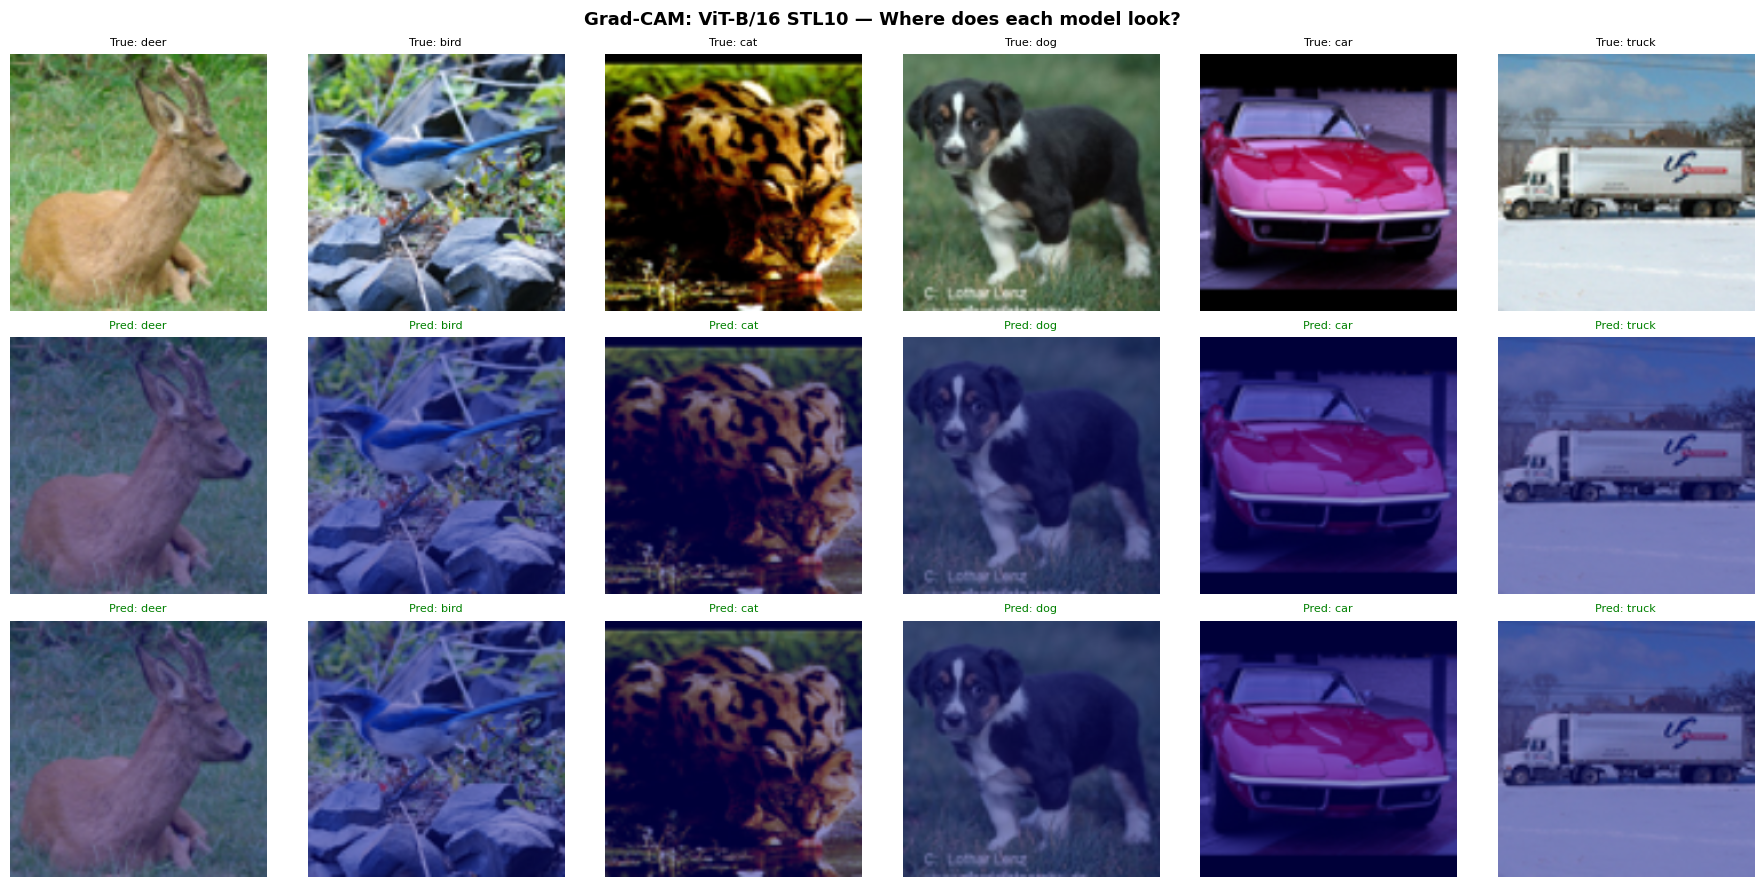

Saved: vit_stl10_gradcam.png


In [11]:
import cv2

def denormalize(tensor):
    # Reverse the ImageNet normalization to recover original pixel values.
    # Formula: original = (normalized * std) + mean
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img  = tensor.permute(1, 2, 0).numpy()  # (C,H,W) -> (H,W,C) for matplotlib
    img  = img * std + mean
    return np.clip(img, 0, 1)


def overlay_heatmap(img_np, cam, alpha=0.45):
    # Resize the 14x14 CAM to 224x224 and blend with the original image.
    # JET colormap: blue=low attention, green=medium, red=high attention.
    # alpha controls heatmap transparency (0=invisible, 1=fully opaque).
    heatmap = cv2.resize(cam, (img_np.shape[1], img_np.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
    return np.clip(alpha * heatmap + (1 - alpha) * img_np, 0, 1)


# Sample 6 random test images
test_images, test_labels = next(iter(torch.utils.data.DataLoader(
    test_dataset, batch_size=6, shuffle=True)))

# Grid: 3 rows x 6 columns
# Row 0: original images
# Row 1: Feature Extraction Grad-CAM
# Row 2: Fine-tuning Grad-CAM
fig, axes = plt.subplots(3, 6, figsize=(18, 9))
fig.suptitle('Grad-CAM: ViT-B/16 STL10 — Where does each model look?',
             fontsize=13, fontweight='bold')
row_titles = ['Original', 'Feature Extraction', 'Fine-tuning']

for col, (img, lbl) in enumerate(zip(test_images, test_labels)):
    img_np = denormalize(img)
    inp    = img.unsqueeze(0).to(device).detach().requires_grad_(True)  # MPS-safe

    cam_fe, pred_fe = gradcam_fe.generate(inp)
    cam_ft, pred_ft = gradcam_ft.generate(inp)

    # Row 0: original image
    axes[0, col].imshow(img_np)
    axes[0, col].set_title(f'True: {CLASSES[lbl]}', fontsize=8)
    axes[0, col].axis('off')

    # Row 1: FE heatmap — green title = correct prediction, red = wrong
    axes[1, col].imshow(overlay_heatmap(img_np, cam_fe))
    axes[1, col].set_title(f'Pred: {CLASSES[pred_fe]}', fontsize=8,
                            color='green' if pred_fe == lbl.item() else 'red')
    axes[1, col].axis('off')

    # Row 2: FT heatmap
    axes[2, col].imshow(overlay_heatmap(img_np, cam_ft))
    axes[2, col].set_title(f'Pred: {CLASSES[pred_ft]}', fontsize=8,
                            color='green' if pred_ft == lbl.item() else 'red')
    axes[2, col].axis('off')

for ax, title in zip(axes[:, 0], row_titles):
    ax.set_ylabel(title, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('vit_stl10_gradcam.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: vit_stl10_gradcam.png')
# What to look for:
# ViT attention maps tend to look blockier than ResNet18 maps
# because ViT operates on discrete 16x16 patches, not continuous conv features.
# This is expected and not a problem — it is a visual property of the architecture.

## 8. Final Comparison — ViT vs ResNet18

In [12]:
# Fill in the ResNet18 results from your executed Assignment 1 notebook
resnet_fe_acc = 93.16  # ResNet18 Feature Extraction — STL10
resnet_ft_acc = 95.54  # ResNet18 Fine-tuning        — STL10

print('=' * 60)
print('FINAL COMPARISON — STL10')
print('=' * 60)
print(f'  {"Model":<25} {"FE Accuracy":>15} {"FT Accuracy":>15}')
print(f'  {"-"*55}')
print(f'  {"ResNet18":<25} {resnet_fe_acc:>14.2f}% {resnet_ft_acc:>14.2f}%')
print(f'  {"ViT-B/16":<25} {acc_fe*100:>14.2f}% {acc_ft*100:>14.2f}%')
print('=' * 60)
print()
print('ViT-B/16 STL10 RESULTS SUMMARY')
print('=' * 60)
print(f'  Feature Extraction')
print(f'    Test Accuracy    : {acc_fe*100:.2f}%')
print(f'    Trainable Params : {count_trainable_params(model_fe):,}')
print(f'    Training Time    : {time_fe/60:.1f} min')
print()
print(f'  Fine-tuning')
print(f'    Test Accuracy    : {acc_ft*100:.2f}%')
print(f'    Trainable Params : {count_trainable_params(model_ft):,}')
print(f'    Training Time    : {time_ft/60:.1f} min')
print()
print(f'  Accuracy gain (FT vs FE): {(acc_ft - acc_fe)*100:+.2f}%')

FINAL COMPARISON — STL10
  Model                         FE Accuracy     FT Accuracy
  -------------------------------------------------------
  ResNet18                           93.16%          95.54%
  ViT-B/16                           98.45%          99.05%

ViT-B/16 STL10 RESULTS SUMMARY
  Feature Extraction
    Test Accuracy    : 98.45%
    Trainable Params : 85,806,346
    Training Time    : 11.3 min

  Fine-tuning
    Test Accuracy    : 99.05%
    Trainable Params : 14,184,970
    Training Time    : 14.3 min

  Accuracy gain (FT vs FE): +0.60%
